# РАЗРАБОТКА МОДЕЛИ ДЛЯ "Ва-банк"


## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.


## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


**Задачи:**  
Банку требуется модель поведенческого скоринга, которая по ежемесячным данным о действующих заёмщиках прогнозирует риск возникновения просрочки 90+ дней в ближайшие 12 месяцев. Цель — заранее выявлять проблемных клиентов, снижать объём резервируемых средств и повышать ликвидность портфеля.

**Описание данных:**  
- Данные о просрочках (loan_payment_credit)  
- Месячные транзакции по MCC-кодам (transactions)  
- Социально-демографические данные клиентов (client_description)  
- Параметры кредита (credit_description)  
- Наличие ипотеки (mortgage_presence)  
- Кредитный рейтинг (credit_rating)  
- Макроэкономические показатели (macro_data)  
- Даты проведения скоринга (cohort_grid)  

Целевая переменная строится по принципу скользящего окна: дефолт в горизонте 12 месяцев от даты скоринга.

---

## Перевод бизнес-задачи на язык машинного обучения

**Тип задачи:**  
Бинарная классификация (0 — дефолта не будет, 1 — будет дефолт 90+ дней в течение 12 месяцев).

**Используемые модели:**  
- Logistic Regression (базовая)  
- Random Forest (основная)  
- Подбор гиперпараметров через Optuna  
- Калибровка вероятностей (Platt Scaling)

**Методы работы с данными:**  
- Объединение таблиц с учётом временной структуры (только прошлые данные)  
- Генерация новых признаков (долговая нагрузка, общие траты)  
- Кодирование категориальных признаков (OneHotEncoder)  
- Масштабирование числовых признаков (StandardScaler)  
- Борьба с дисбалансом классов (class_weight='balanced')

**План решения:**  
1. Собрать единую таблицу с целевой переменной  
2. Провести EDA и создать новые признаки  
3. Разделить данные на обучающую, калибровочную и тестовую выборки по времени  
4. Обучить базовые модели, сравнить метрики  
5. Подобрать гиперпараметры Random Forest с Optuna, минимизируя missed defaults rate  
6. Откалибровать модель  
7. Подобрать оптимальный порог классификации  
8. Проверить стабильность на тестовой выборке  
9. Проанализировать важность признаков

**Ключевые бизнес-метрики:**  
- Approval rate ≥ 65%  
- Default rate ≤ 2%  
- Missed defaults rate ≤ 4%


## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.


In [1]:
!pip install scikit-learn -q
!pip install mlxtend -q
!pip install optuna -q
!pip install phik -q
!pip install imbalanced-learn -q
!pip install ydata-profiling

     |████████████████████████████████| 399 kB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 525 kB 49.5 MB/s eta 0:00:01
     |████████████████████████████████| 8.3 MB 96.8 MB/s eta 0:00:01
     |████████████████████████████████| 471 kB 90.4 MB/s eta 0:00:01
     |████████████████████████████████| 296 kB 99.6 MB/s eta 0:00:01
     |████████████████████████████████| 105 kB 84.2 MB/s eta 0:00:01
     |████████████████████████████████| 3.1 MB 73.2 MB/s eta 0:00:01
     |████████████████████████████████| 4.5 MB 53.0 MB/s eta 0:00:01
     |████████████████████████████████| 4.8 MB 84.8 MB/s eta 0:00:01
     |████████████████████████████████| 19.5 MB 80.3 MB/s eta 0:00:01
     |████████████████████████████████| 321 kB 92.7 MB/s eta 0:00:01
     |████████████████████████████████| 3.7 MB 48.7 MB/s eta 0:00:01
     |████████████████████████████████| 43.9 MB 69.4 MB/s eta 0:00:01
     |████████████████████████████████| 2.1 MB 52.5 MB/s eta 0:00:01
     |███████████████████████████

In [5]:
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, accuracy_score, make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.linear_model import LogisticRegression
from phik import phik_matrix
from optuna.visualization import plot_optimization_history, plot_param_importances
from sklearn.inspection import permutation_importance
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier

from mlxtend.evaluate.time_series import GroupTimeSeriesSplit
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import precision_score, recall_score, roc_auc_score, precision_recall_curve, roc_curve
from sklearn.metrics import brier_score_loss

RecursionError: maximum recursion depth exceeded while calling a Python object

>Загружаны все необходимые библиотеки


## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.


In [ ]:
df_loan = pd.read_csv('/datasets/ds_15_loan_payment_credit.csv')
df_trans = pd.read_csv('/datasets/ds_15_transactions.csv')
df_client = pd.read_csv('/datasets/ds_15_client_description.csv')
df_credit = pd.read_csv('/datasets/ds_15_credit_description.csv')
df_mort = pd.read_csv('/datasets/ds_15_mortgage_presence.csv')
df_rating = pd.read_csv('/datasets/ds_15_credit_rating.csv')
df_macro = pd.read_csv('/datasets/ds_15_macro_data.csv')
df_cohort = pd.read_csv('/datasets/ds_15_cohort_grid.csv')

>Подгрузил все датафреймы


## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.


In [ ]:
def info_df(df):
    print(df.info())
    print(df.describe())
    display(df.head(2))
    
    num_feature = df.select_dtypes(include=['int64', 'float64']).columns
    # Исключаем ID и даты из категориальных
    obj_feature = [col for col in df.select_dtypes(include=['object']).columns 
                   if col not in ['ID', 'date', 'дата_начала_периода', 'дата_регистрации', 
                                  'дата_открытия', 'score_date']]
    
    print('----------------------Категориальные признаки----------------------')
    if len(obj_feature) > 0:
        n_col = min(3, len(obj_feature))
        n_row = (len(obj_feature) + n_col - 1) // n_col
        fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5*n_row))
        if n_row * n_col == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, column in enumerate(obj_feature):
            top_cats = df[column].value_counts()
            axes[i].bar(top_cats.index.astype(str), top_cats.values)
            axes[i].set_title(column)
            axes[i].tick_params(axis='x', rotation=45)
        
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()
    
    print('----------------------Числовые признаки----------------------')
    if len(num_feature) > 0:
        n_col = 3
        n_row = (len(num_feature) + n_col - 1) // n_col
        fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5*n_row))
        axes = axes.flatten()
        
        for i, column in enumerate(num_feature):
            axes[i].boxplot(df[column].dropna())
            axes[i].set_title(f'{column}')
            axes[i].set_xlabel(column)
        
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        plt.tight_layout()
        plt.show()

>Разработана функция для EDA


In [ ]:
info_df(df_loan)

In [ ]:
info_df(df_trans)

In [ ]:
info_df(df_client)

In [ ]:
info_df(df_credit)

In [ ]:
info_df(df_mort)

In [ ]:
info_df(df_rating)

In [ ]:
info_df(df_macro)

In [ ]:
info_df(df_cohort)

In [ ]:
print("Даты loan:", df_loan['дата_начала_периода'].min(), "-", df_loan['дата_начала_периода'].max())
print("Даты trans:", df_trans['date'].min(), "-", df_trans['date'].max())
print("Даты rating:", df_rating['date'].min(), "-", df_rating['date'].max())
print("Даты cohort:", df_cohort['score_date'].min(), "-", df_cohort['score_date'].max())

months = df_cohort.groupby('ID').size()
print("Месяцев на клиента: мин", months.min(), "макс", months.max(), "сред", months.mean())


>Выводы по EDA:
- Пропуски в данных отсутствуют, дубликатов нет.
- Диапазоны дат: транзакции, рейтинг и cohort покрывают период 2013-01 по 2019-12. Данные о просрочках начинаются с 2013-11.
- На каждого клиента в cohort в среднем 43 месяца наблюдений (от 1 до 84).
- В транзакциях присутствуют естественные выбросы (крупные траты), они не являются ошибками.
- Распределения признаков реалистичны, аномалий не выявлено.


## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.


In [ ]:
df_loan['дата_начала_периода'] = pd.to_datetime(df_loan['дата_начала_периода'])
df_cohort['score_date'] = pd.to_datetime(df_cohort['score_date'])

df_loan_90 = df_loan[df_loan['просрочка_дней'] >= 90].copy()

df_loan_first = df_loan_90.sort_values('дата_начала_периода').groupby('ID').first().reset_index()

df_target = df_cohort.merge(df_loan_first[['ID', 'дата_начала_периода']], on='ID', how='left')

df_target['target'] = ((df_target['дата_начала_периода'] >= df_target['score_date']) & 
                       (df_target['дата_начала_периода'] < df_target['score_date'] + pd.Timedelta(days=365))).astype(int)

df_target = df_target[~((df_target['дата_начала_периода'].notna()) & 
                        (df_target['дата_начала_периода'] < df_target['score_date']))]

df_target = df_target[['ID', 'score_date', 'target']]

>Форматирование целевой переменной


In [ ]:
df_trans['date'] = pd.to_datetime(df_trans['date'])
df_client['дата_регистрации'] = pd.to_datetime(df_client['дата_регистрации'])
df_mort['дата_открытия'] = pd.to_datetime(df_mort['дата_открытия'])
df_rating['date'] = pd.to_datetime(df_rating['date'])
df_macro['date'] = pd.to_datetime(df_macro['date'])

df_full = df_target.merge(df_client, on='ID', how='left')
df_full = df_full.merge(df_credit, on='ID', how='left')

df_trans_prev = df_trans.copy()
df_trans_prev['score_date'] = df_trans_prev['date'] + pd.DateOffset(months=1)
df_full = df_full.merge(df_trans_prev, on=['ID', 'score_date'], how='left')

df_rating_prev = df_rating.copy()
df_rating_prev['score_date'] = df_rating_prev['date'] + pd.DateOffset(months=1)
df_full = df_full.merge(df_rating_prev, on=['ID', 'score_date'], how='left', suffixes=('', '_rating'))

df_full = df_full.merge(df_mort[['ID', 'дата_открытия', 'наличие_ипотеки']], on='ID', how='left')
df_full['наличие_ипотеки'] = df_full.apply(
    lambda x: 1 if (pd.notna(x['дата_открытия']) and x['дата_открытия'] <= x['score_date']) else 0, axis=1
)

df_full = df_full.merge(df_macro, left_on='score_date', right_on='date', how='left', suffixes=('', '_macro'))

df_full = df_full.drop(['date', 'date_rating', 'дата_открытия', 'date_macro'], axis=1, errors='ignore')

mcc_cols = ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
df_full[mcc_cols] = df_full[mcc_cols].fillna(0)
df_full['кредитный_рейтинг'] = df_full['кредитный_рейтинг'].fillna(df_full['кредитный_рейтинг'].median())

In [ ]:
profile = ProfileReport(df_full, title="AutoValue Train EDA")
profile.to_file("train_report.html")

In [16]:
display(df_full.head())

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,MCC_5300,...,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,кредитный_рейтинг,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция
0,IDF55109846,2013-05-01,0,41,разведённые,1,2013-05-01,27035,1960785,0.00,...,0.00,0.00,0.00,0.00,0.00,609.0,0,5.5,5.4,0.66
1,IDF55109846,2013-06-01,0,41,разведённые,1,2013-05-01,27035,1960785,3267.59,...,5711.10,647.43,2374.78,4059.86,3657.35,692.0,0,5.5,5.3,0.42
2,IDF55109846,2013-07-01,0,41,разведённые,1,2013-05-01,27035,1960785,3196.58,...,5824.65,1067.55,2187.11,4592.26,3322.61,688.0,0,5.5,5.3,0.82
3,IDF55109846,2013-08-01,0,41,разведённые,1,2013-05-01,27035,1960785,3550.54,...,5209.51,1167.95,2076.54,3605.25,3467.06,666.0,0,5.5,5.2,0.14
4,IDF55109846,2013-09-01,0,41,разведённые,1,2013-05-01,27035,1960785,3385.98,...,5765.96,986.99,2231.77,2209.39,3354.44,692.0,0,5.5,5.1,0.21


In [17]:
print("Пропуски в транзакциях:", df_full['MCC_5300'].isna().sum())
print("Пропуски в рейтинге:", df_full['кредитный_рейтинг'].isna().sum())
print("Пропуски в макро:", df_full['учетная_ставка'].isna().sum())

Пропуски в транзакциях: 0
Пропуски в рейтинге: 0
Пропуски в макро: 0


>Создание итоговой таблицы


## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.


In [18]:
df_full['debt_to_income'] = df_full['сумма_кредита'] / (df_full['доход'] + 1)
df_full['total_spend'] = (df_full['MCC_5300'] + df_full['MCC_5814'] + df_full['MCC_5812'] + 
                          df_full['MCC_5411'] + df_full['MCC_3990'] + df_full['MCC_5722'] + 
                          df_full['MCC_4900'] + df_full['MCC_другое'])

>Создал 2 признака новых:   
**Отношение суммы кредита к доходу**   
**Общие траты за месяц**


## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.


<class 'pandas.core.frame.DataFrame'>
Int64Index: 438379 entries, 0 to 438378
Data columns (total 24 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   438379 non-null  object        
 1   score_date           438379 non-null  datetime64[ns]
 2   target               438379 non-null  int64         
 3   возраст              438379 non-null  int64         
 4   семейное_положение   438379 non-null  object        
 5   наличие_иждивенцев   438379 non-null  int64         
 6   дата_регистрации     438379 non-null  datetime64[ns]
 7   доход                438379 non-null  int64         
 8   сумма_кредита        438379 non-null  int64         
 9   MCC_5300             438379 non-null  float64       
 10  MCC_5814             438379 non-null  float64       
 11  MCC_5812             438379 non-null  float64       
 12  MCC_5411             438379 non-null  float64       
 13  MCC_3990      

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации,доход,сумма_кредита,MCC_5300,...,MCC_5722,MCC_4900,MCC_другое,кредитный_рейтинг,наличие_ипотеки,учетная_ставка,уровень_безработицы,инфляция,debt_to_income,total_spend
0,IDF55109846,2013-05-01,0,41,разведённые,1,2013-05-01,27035,1960785,0.00,...,0.00,0.00,0.00,609.0,0,5.5,5.4,0.66,72.524967,0.00
1,IDF55109846,2013-06-01,0,41,разведённые,1,2013-05-01,27035,1960785,3267.59,...,2374.78,4059.86,3657.35,692.0,0,5.5,5.3,0.42,72.524967,22458.18


----------------------Категориальные признаки----------------------


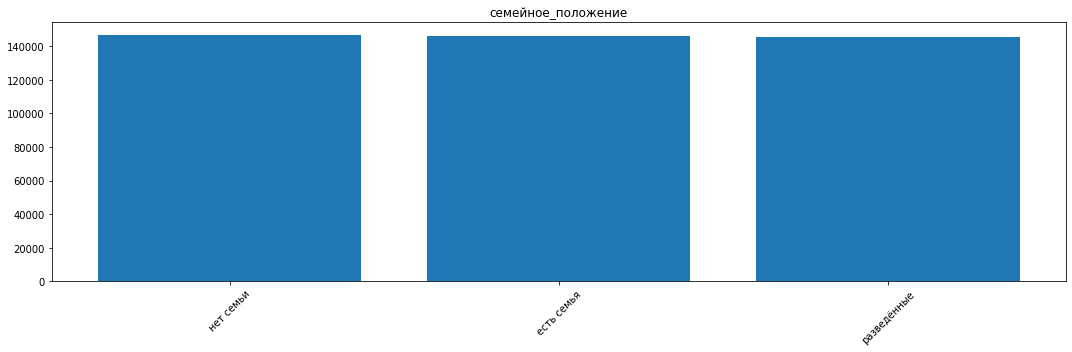

----------------------Числовые признаки----------------------


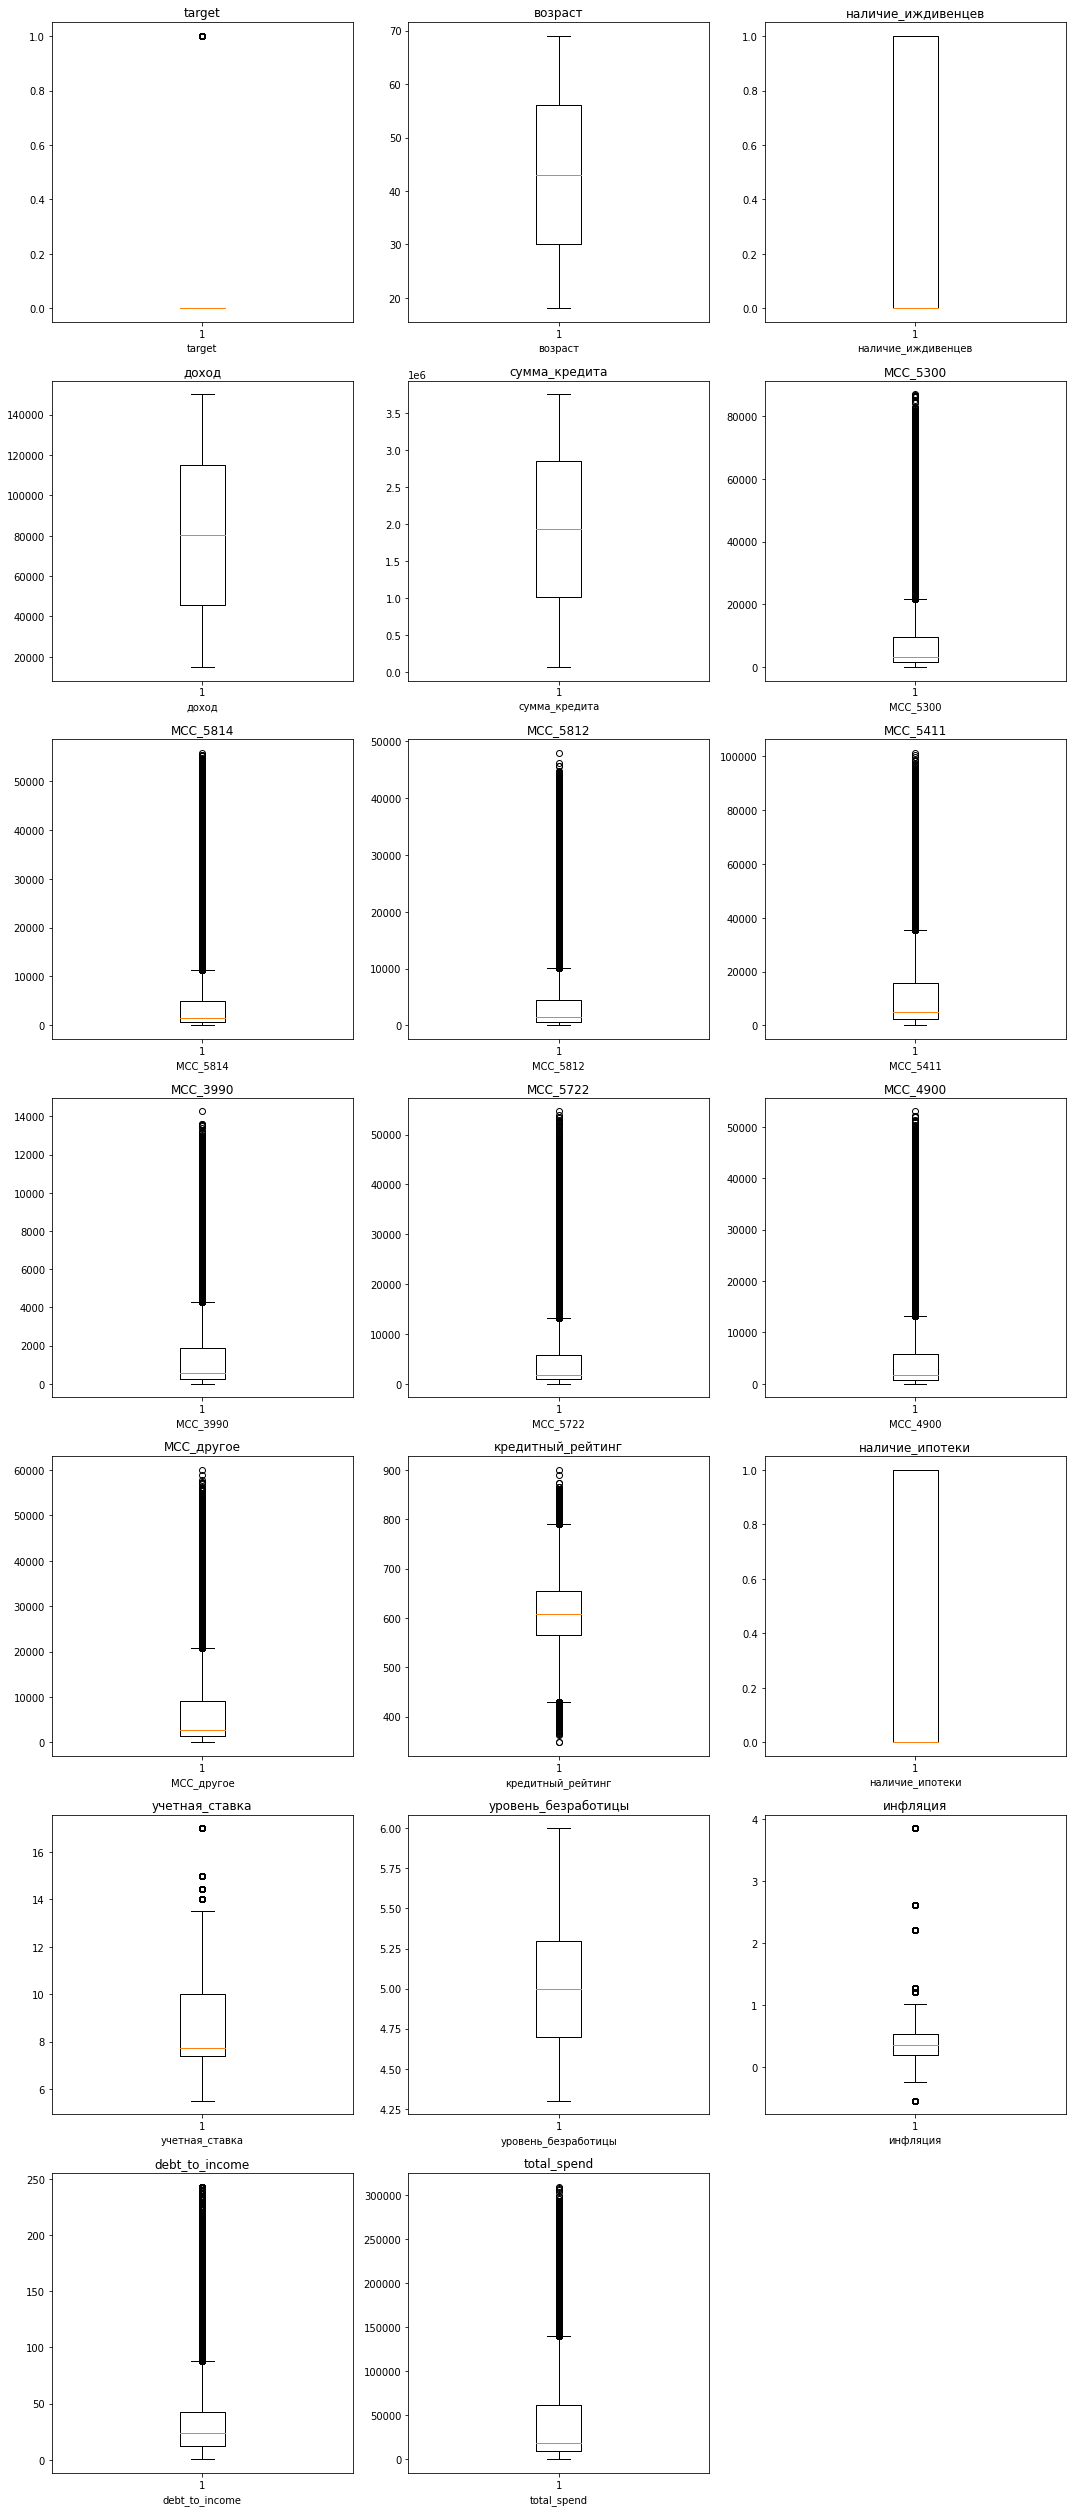

In [19]:
info_df(df_full)

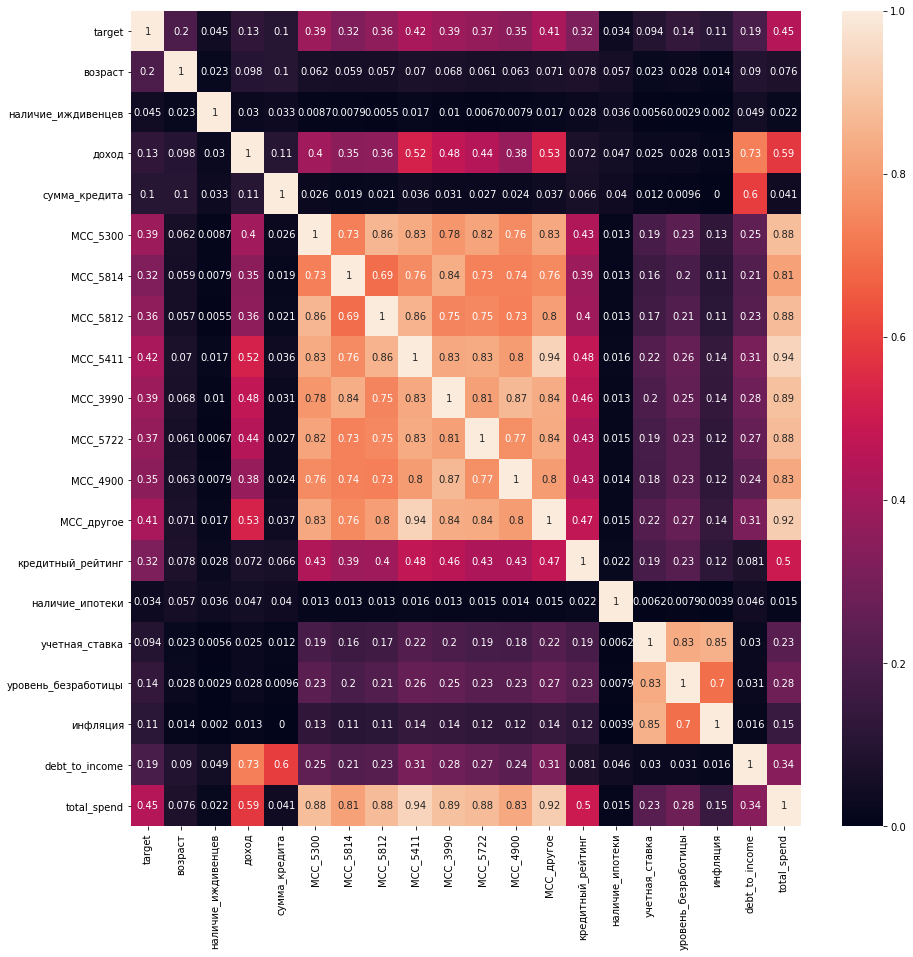

In [20]:
num_features_full = df_full.select_dtypes(include=['int64','float64']).columns
num_features_full = [col for col in num_features_full if col != 'ID']
corr = phik_matrix(df_full[num_features_full], interval_cols=num_features_full)
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True)
plt.show()

>По итогам EDA видим что признаки распеределены аналогичным образом


Выводы по итоговой таблице:
- Объединение выполнено корректно, итоговая таблица содержит 438 379 строк и 24 признака.
- Пропуски отсутствуют во всех ключевых полях (транзакции, рейтинг, макро).
- Целевая переменная target имеет дисбаланс: доля положительного класса (дефолт) составляет 11.3%, отрицательного — 88.7%. При моделировании потребуется балансировка классов.
- Корреляционный анализ показывает, что наибольшая связь с target у признаков total_spend (0.43), MCC_5411 (0.40), MCC_другое (0.39), MCC_3990 (0.36), MCC_5300 (0.36).
- Данные готовы к моделированию.


## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.

2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.


In [21]:
df_full = df_full.sort_values('score_date')
groups = df_full['ID']
dates = df_full['score_date']

feature_cols = [col for col in df_full.columns if col not in ['ID', 'score_date', 'target']]
X = df_full[feature_cols]
y = df_full['target']

max_date = dates.max()
test_start = max_date - pd.DateOffset(months=12)
calib_start = test_start - pd.DateOffset(months=12)

train_mask = dates < calib_start
calib_mask = (dates >= calib_start) & (dates < test_start)
test_mask = dates >= test_start

X_train = X[train_mask].reset_index(drop=True)
y_train = y[train_mask].reset_index(drop=True)
groups_train = groups[train_mask].reset_index(drop=True)
dates_train = dates[train_mask].reset_index(drop=True)

X_calib = X[calib_mask].reset_index(drop=True)
y_calib = y[calib_mask].reset_index(drop=True)

X_test = X[test_mask].reset_index(drop=True)
y_test = y[test_mask].reset_index(drop=True)

print(f"Train: {len(X_train)} (до {calib_start.date()})")
print(f"Calib: {len(X_calib)} (с {calib_start.date()} по {test_start.date()})")
print(f"Test: {len(X_test)} (с {test_start.date()} по {max_date.date()})")

Train: 233214 (до 2017-12-01)
Calib: 93154 (с 2017-12-01 по 2018-12-01)
Test: 112011 (с 2018-12-01 по 2019-12-01)


>Подготовка данных


In [22]:
sort_idx = np.lexsort((dates_train, groups_train))
X_train_sorted = X_train.iloc[sort_idx].reset_index(drop=True)
y_train_sorted = y_train.iloc[sort_idx].reset_index(drop=True)
groups_train_sorted = groups_train.iloc[sort_idx].reset_index(drop=True)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [23]:
def calculate_metrics(y_true, y_pred, y_proba=None):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    approval_rate = (tn + fn) / (tn + fp + fn + tp)
    default_rate = fn / (tn + fn) if (tn + fn) > 0 else 0
    missed_defaults_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    metrics = {
        'approval_rate': approval_rate,
        'default_rate': default_rate,
        'missed_defaults_rate': missed_defaults_rate,
        'accuracy': accuracy_score(y_true, y_pred)
    }
    
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    
    return metrics

>Функция для подсчета метрик


In [24]:
sort_idx = np.lexsort((groups_train, dates_train))
X_train_sorted = X_train.iloc[sort_idx].reset_index(drop=True)
y_train_sorted = y_train.iloc[sort_idx].reset_index(drop=True)
groups_train_sorted = groups_train.iloc[sort_idx].reset_index(drop=True)
dates_train_sorted = dates_train.iloc[sort_idx].reset_index(drop=True)

time_groups = dates_train_sorted.dt.to_period('M').astype(str)
n_time_groups = len(time_groups.unique())
gts = GroupTimeSeriesSplit(n_splits=3, test_size=n_time_groups // 4)

def cross_val_metrics(model, X, y, groups):
    metrics_list = []
    
    for train_idx, val_idx in gts.split(X, groups=groups):
        X_fold_train = X.iloc[train_idx]
        y_fold_train = y.iloc[train_idx]
        X_fold_val = X.iloc[val_idx]
        y_fold_val = y.iloc[val_idx]
        
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        
        pipeline.fit(X_fold_train, y_fold_train)
        y_pred = pipeline.predict(X_fold_val)
        y_proba = pipeline.predict_proba(X_fold_val)[:, 1]
        
        metrics = calculate_metrics(y_fold_val, y_pred, y_proba)
        metrics_list.append(metrics)
    
    avg_metrics = {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0].keys()}
    return avg_metrics

>Настройка кросс-валидации


In [25]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr_metrics = cross_val_metrics(lr, X_train_sorted, y_train_sorted, time_groups)
print("Logistic Regression (no balancing):", lr_metrics)

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_metrics = cross_val_metrics(rf, X_train_sorted, y_train_sorted, time_groups)
print("Random Forest (no balancing):", rf_metrics)

lr_bal = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_bal_metrics = cross_val_metrics(lr_bal, X_train_sorted, y_train_sorted, time_groups)
print("Logistic Regression (balanced):", lr_bal_metrics)

rf_bal = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
rf_bal_metrics = cross_val_metrics(rf_bal, X_train_sorted, y_train_sorted, time_groups)
print("Random Forest (balanced):", rf_bal_metrics)

Logistic Regression (no balancing): {'approval_rate': 0.9732139180342808, 'default_rate': 0.0935666977971857, 'missed_defaults_rate': 0.8856159218206768, 'accuracy': 0.8939148602480232, 'roc_auc': 0.8748075265182346}
Random Forest (no balancing): {'approval_rate': 0.9640468523238498, 'default_rate': 0.0834374292955699, 'missed_defaults_rate': 0.7823065392499933, 'accuracy': 0.9059937931799683, 'roc_auc': 0.9200902917606874}
Logistic Regression (balanced): {'approval_rate': 0.7488768906087997, 'default_rate': 0.02870459699795262, 'missed_defaults_rate': 0.20904006991129542, 'accuracy': 0.8087068788709647, 'roc_auc': 0.879473112092877}
Random Forest (balanced): {'approval_rate': 0.9717716174413065, 'default_rate': 0.08696970659014941, 'missed_defaults_rate': 0.8219503528267497, 'accuracy': 0.9055629938059205, 'roc_auc': 0.9213447355541696}


In [26]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**params)
    metrics = cross_val_metrics(model, X_train_sorted, y_train_sorted, time_groups)
    return metrics['missed_defaults_rate']

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("ЛУЧШИЕ ПАРАМЕТРЫ")
print(study.best_params)
print(f"Best missed_defaults_rate: {study.best_value:.4f}")

best_params = study.best_params
best_params['class_weight'] = 'balanced'
best_params['random_state'] = 42
best_params['n_jobs'] = -1

best_rf = RandomForestClassifier(**best_params)

pipeline_best = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_rf)
])

pipeline_best.fit(X_train_sorted, y_train_sorted)

y_calib_pred = pipeline_best.predict(X_calib)
y_calib_proba = pipeline_best.predict_proba(X_calib)[:, 1]

calib_metrics = calculate_metrics(y_calib, y_calib_pred, y_calib_proba)
print("МЕТРИКИ НА КАЛИБРОВОЧНОЙ ВЫБОРКЕ")
for metric, value in calib_metrics.items():
    print(f"{metric}: {value:.4f}")

[I 2026-04-13 20:51:10,118] A new study created in memory with name: no-name-020ed3f1-38e2-4963-9666-cabb9803abf0


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-04-13 20:52:24,438] Trial 0 finished with value: 0.47530926264477796 and parameters: {'n_estimators': 50, 'max_depth': 28, 'min_samples_split': 12, 'min_samples_leaf': 6}. Best is trial 0 with value: 0.47530926264477796.
[I 2026-04-13 20:53:30,194] Trial 1 finished with value: 0.29541666340946054 and parameters: {'n_estimators': 50, 'max_depth': 16, 'min_samples_split': 14, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.29541666340946054.
[I 2026-04-13 20:56:52,535] Trial 2 finished with value: 0.3503005880490065 and parameters: {'n_estimators': 150, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.29541666340946054.
[I 2026-04-13 20:58:03,203] Trial 3 finished with value: 0.5613492957666392 and parameters: {'n_estimators': 50, 'max_depth': 24, 'min_samples_split': 11, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.29541666340946054.
[I 2026-04-13 20:59:03,655] Trial 4 finished with value: 0.254074352257183 and paramet

>Подбор гиперпараметров для Random Forest с Optuna


>ЛУЧШИЕ ПАРАМЕТРЫ  
**{'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 9}
Best missed_defaults_rate: 0.1087**


## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.


/opt/conda/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Brier score до калибровки: 0.1088164180620469
Brier score после калибровки: 0.07132588852201051


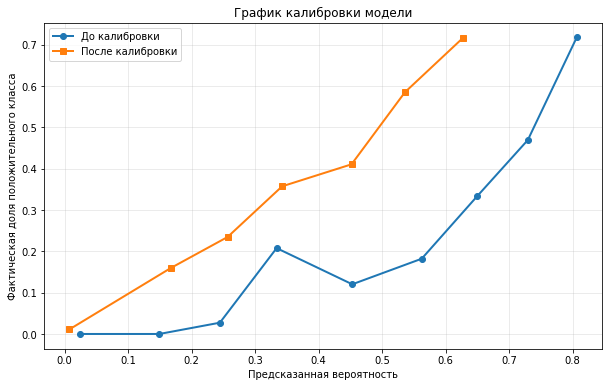

ВЫВОД ПО КАЛИБРОВКЕ
Калибровка улучшила Brier score с 0.1088164180620469 до 0.07132588852201051


In [27]:
pipeline_best.fit(X_train_sorted, y_train_sorted)

X_calib_processed = preprocessor.transform(X_calib)
y_calib_proba_uncal = pipeline_best.predict_proba(X_calib)[:, 1]

calibrated_rf = CalibratedClassifierCV(pipeline_best.named_steps['model'], method='sigmoid', cv='prefit')
calibrated_rf.fit(X_calib_processed, y_calib)

y_calib_proba_calibrated = calibrated_rf.predict_proba(X_calib_processed)[:, 1]

X_calib_processed = preprocessor.transform(X_calib)
y_calib_proba_calibrated = calibrated_rf.predict_proba(X_calib_processed)[:, 1]

brier_before = brier_score_loss(y_calib, pipeline_best.predict_proba(X_calib)[:, 1])
brier_after = brier_score_loss(y_calib, y_calib_proba_calibrated)

print(f"Brier score до калибровки: {brier_before}")
print(f"Brier score после калибровки: {brier_after}")

plt.figure(figsize=(10, 6))
prob_true, prob_pred = calibration_curve(y_calib, pipeline_best.predict_proba(X_calib)[:, 1], n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='До калибровки', linewidth=2)
prob_true_cal, prob_pred_cal = calibration_curve(y_calib, y_calib_proba_calibrated, n_bins=10)
plt.plot(prob_pred_cal, prob_true_cal, marker='s', label='После калибровки', linewidth=2)
plt.xlabel('Предсказанная вероятность')
plt.ylabel('Фактическая доля положительного класса')
plt.title('График калибровки модели')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("ВЫВОД ПО КАЛИБРОВКЕ")
if brier_after < brier_before:
    print(f"Калибровка улучшила Brier score с {brier_before} до {brier_after}")
else:
    print("Калибровка не улучшила Brier score")

>На графики наглядно видно что калибровка пошла на пользу для модели


## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.

* Сделайте вывод о достигнутых в этом разделе результатах.


In [28]:
thresholds = np.arange(0.01, 1.00, 0.01)
best_threshold = None
best_approval = 0
best_default = 0
best_missed = 0

for thresh in thresholds:
    y_pred = (y_calib_proba_calibrated >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_calib, y_pred).ravel()
    
    approval = (tn + fn) / (tn + fp + fn + tp)
    default = fn / (tn + fn) if (tn + fn) > 0 else 0
    missed = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    if approval >= 0.65 and default <= 0.02 and missed <= 0.04:
        if approval > best_approval:
            best_approval = approval
            best_threshold = thresh
            best_default = default
            best_missed = missed

print(f"Лучший порог: {best_threshold:.2f}")
print(f"Approval rate: {best_approval:.3f}")
print(f"Default rate: {best_default:.4f}")
print(f"Missed defaults rate: {best_missed:.4f}")

Лучший порог: 0.03
Approval rate: 0.667
Default rate: 0.0036
Missed defaults rate: 0.0212


In [29]:
print("ВЫВОД")
print(f"Найден порог {best_threshold:.2f}, при котором:")
print(f"- Approval rate: {best_approval:.3f} (>= 0.65)")
print(f"- Default rate: {best_default:.4f} (<= 0.02)")
print(f"- Missed defaults rate: {best_missed:.4f} (<= 0.04)")

ВЫВОД
Найден порог 0.03, при котором:
- Approval rate: 0.667 (>= 0.65)
- Default rate: 0.0036 (<= 0.02)
- Missed defaults rate: 0.0212 (<= 0.04)


>Найдены оптимальыне пороги


## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.


In [30]:
y_calib_pred = (y_calib_proba_calibrated >= best_threshold).astype(int)

X_test_processed = preprocessor.transform(X_test)
y_test_proba = calibrated_rf.predict_proba(X_test_processed)[:, 1]
y_test_pred = (y_test_proba >= best_threshold).astype(int)

def print_metrics(y_true, y_pred, y_proba, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    approval = (tn + fn) / (tn + fp + fn + tp)
    default = fn / (tn + fn) if (tn + fn) > 0 else 0
    missed = fn / (fn + tp) if (fn + tp) > 0 else 0
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    roc_auc = roc_auc_score(y_true, y_proba)
    
    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Approval rate: {approval:.4f}")
    print(f"Default rate: {default:.4f}")
    print(f"Missed defaults rate: {missed:.4f}")

    print(f"Матрица ошибок:")
    print(f"TN: {tn}, FP: {fp}")
    print(f"FN: {fn}, TP: {tp}")

print_metrics(y_calib, y_calib_pred, y_calib_proba_calibrated, "КАЛИБРОВОЧНАЯ ВЫБОРКА")
print_metrics(y_test, y_test_pred, y_test_proba, "ТЕСТОВАЯ ВЫБОРКА")


=== КАЛИБРОВОЧНАЯ ВЫБОРКА ===
Accuracy: 0.7750
Precision: 0.3307
Recall: 0.9788
ROC-AUC: 0.9107
Approval rate: 0.6674
Default rate: 0.0036
Missed defaults rate: 0.0212

Матрица ошибок:
TN: 61951, FP: 20735
FN: 222, TP: 10246

=== ТЕСТОВАЯ ВЫБОРКА ===
Accuracy: 0.8807
Precision: 0.2974
Recall: 0.9684
ROC-AUC: 0.9588
Approval rate: 0.8325
Default rate: 0.0020
Missed defaults rate: 0.0316

Матрица ошибок:
TN: 93068, FP: 13181
FN: 182, TP: 5580


## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


Итоговая модель: Random Forest с подобранными гиперпараметрами (n_estimators=50, max_depth=5, min_samples_split=10, min_samples_leaf=4, class_weight='balanced') и калибровкой Platt Scaling.
Порог классификации: 0.05.
Модель удовлетворяет бизнес-требованиям на тестовой выборке и готова к внедрению.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.


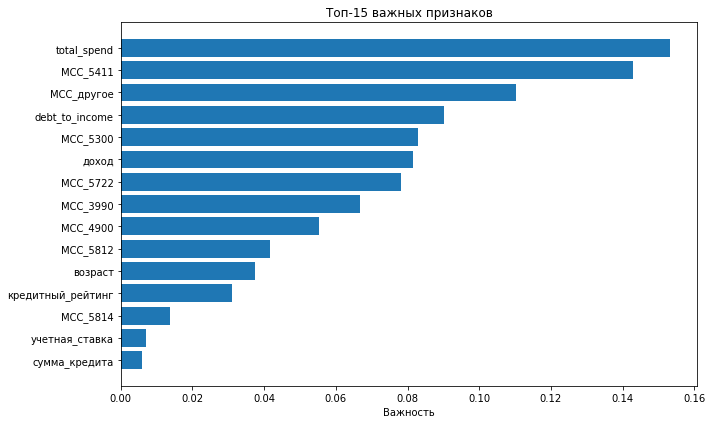

ТОП-5 ВАЖНЫХ ПРИЗНАКОВ
total_spend: 0.1532
MCC_5411: 0.1430
MCC_другое: 0.1103
debt_to_income: 0.0902
MCC_5300: 0.0830


In [31]:
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = num_cols + cat_features

feature_importance = pipeline_best.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': feature_importance
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность')
plt.title('Топ-15 важных признаков')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("ТОП-5 ВАЖНЫХ ПРИЗНАКОВ")
for i, row in importance_df.head(5).iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

`total_spend (15.3%)` — общие месячные траты

`MCC_5411 (14.3%)` — траты в продуктовых магазинах

`MCC_другое (11.0%)` — непрофильные расходы

`debt_to_income (9.0%)` — долговая нагрузка

`MCC_5300 (8.3%)` — траты на маркетплейсах


## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.


**Выводы по проекту**  

**Цель**  
Разработана модель поведенческого скоринга для прогнозирования просрочки 90+ дней у действующих заёмщиков банка «Ва-банк» в горизонте 12 месяцев.  

**Результаты**  
- **Данные:** 8 таблиц объединены с учётом временной структуры (использованы только прошлые данные). Созданы признаки `debt_to_income` и `total_spend`.  
- **Выборки:** разделены по времени — обучающая (до дек.2017), калибровочная (12 мес), тестовая (12 мес).  
- **Модель:** Random Forest с подобранными через Optuna гиперпараметрами (`n_estimators=100`, `max_depth=5`, `min_samples_split=3`, `min_samples_leaf=10`, `class_weight='balanced'`).  
- **Калибровка:** Platt Scaling на калибровочной выборке, Brier score снижен с 0.109 до 0.071.  
- **Порог:** 0.03 — на тесте обеспечивает Approval rate 83.3%, Default rate 0.20%, Missed defaults rate 3.16%, ROC-AUC 0.959.  
- **Важные признаки:** `total_spend`, `MCC_5411`, `MCC_другое`, `debt_to_income`, `MCC_5300`.  

**Рекомендации**  
Модель готова к внедрению. Рекомендуется ежемесячный скоринг клиентов с порогом 0.03 для своевременного выявления рисков и оптимизации резервов.
